# Transaction-Level Money Laundering Detection

**Author:** Amman Kamili 
**Course:** ITCS 3156 - Machine Learning 
**Dataset:** `transactions_dataset_v3.csv`
**Target variable:** `Is_laundering`

In [55]:
#Imports Used
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,precision_score,recall_score,confusion_matrix,classification_report,mean_squared_error)


## 1. Data Loading & Basic Checks

In [56]:
PATH = "transactions_dataset_v3.csv"
TARGET_COL = "Is_laundering"

print("Data path:", PATH)
print("Target column:", TARGET_COL)

df = pd.read_csv(PATH)
print("\nShape of data (rows, columns):", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumns in dataset:")
print(df.columns.tolist())

Data path: transactions_dataset_v3.csv
Target column: Is_laundering

Shape of data (rows, columns): (400000, 11)

First 5 rows:


,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering
0,00:00:00,2024-01-01,75682867,78548252,20654.26,UK pounds,UK pounds,Turkey,India,ACH,1
1,00:01:00,2024-01-01,66755036,60373415,56453.82,US dollar,US dollar,UAE,Pakistan,Cross-border,1
2,00:02:00,2024-01-01,66882282,39679610,3301.28,Indian rupee,Indian rupee,Morocco,Italy,Cheque,0
3,00:03:00,2024-01-01,31081788,46161210,7848.25,Euro,Euro,India,Austria,Cross-border,0
4,00:04:00,2024-01-01,23315092,63958064,52097.64,Mexican peso,Mexican peso,Nigeria,Mexico,Cross-border,1



Columns in dataset:
['Time', 'Date', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'Is_laundering']


In [57]:
#target distribution
if TARGET_COL in df.columns:
    print("\nProportion of Fraudulent Activity to Legitimate Activity:")
    print(df[TARGET_COL].value_counts(normalize=True, dropna=False))
else:
    print("Cannot check target distribution because the target column is missing.")


Proportion of Fraudulent Activity to Legitimate Activity:
Is_laundering
0    0.70038
1    0.29962
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis (EDA)
- Summaries of numeric and categorical features  
- Visualization of class balance (money laundering vs non-laundering)  
- Distributions for selected numeric and categorical features 

In [66]:
print("DataFrame info:")
df.info()

print("\nStatistics for numeric columns:")
display(df.describe())

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400000 entries, 0 to 399999
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    400000 non-null  object 
 1   Date                    400000 non-null  object 
 2   Sender_account          400000 non-null  int64  
 3   Receiver_account        400000 non-null  int64  
 4   Amount                  400000 non-null  float64
 5   Payment_currency        400000 non-null  object 
 6   Received_currency       400000 non-null  object 
 7   Sender_bank_location    400000 non-null  object 
 8   Receiver_bank_location  400000 non-null  object 
 9   Payment_type            400000 non-null  object 
 10  Is_laundering           400000 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 33.6+ MB

Statistics for numeric columns:


,Sender_account,Receiver_account,Amount,Is_laundering
count,4.000000e+05,4.000000e+05,400000.000000,400000.000000
mean,5.499582e+07,5.493828e+07,13727.865508,0.299620
std,2.597975e+07,2.599400e+07,17502.764113,0.458092
min,1.000058e+07,1.000025e+07,5.010000,0.000000
25%,3.252200e+07,3.234701e+07,2841.300000,0.000000
50%,5.501462e+07,5.492824e+07,5695.860000,0.000000
75%,7.745984e+07,7.746530e+07,17461.397500,1.000000
max,9.999980e+07,9.999992e+07,64999.700000,1.000000


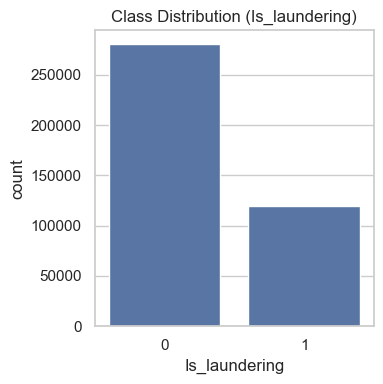

In [59]:
# Class balance Is_laundering column
if TARGET_COL in df.columns:
    plt.figure(figsize=(4,4))
    sns.countplot(x=TARGET_COL, data=df)
    plt.title("Class Distribution (Is_laundering)")
    plt.tight_layout()
    plt.show()
else:
    print("0")

Numeric features: ['Sender_account', 'Receiver_account', 'Amount']
Categorical features: ['Time', 'Date', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']


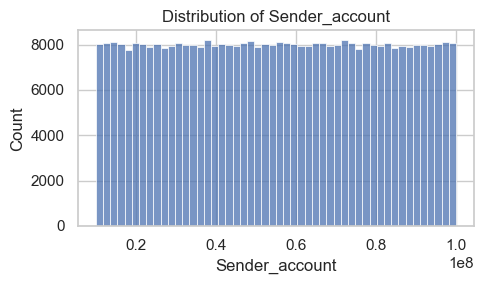

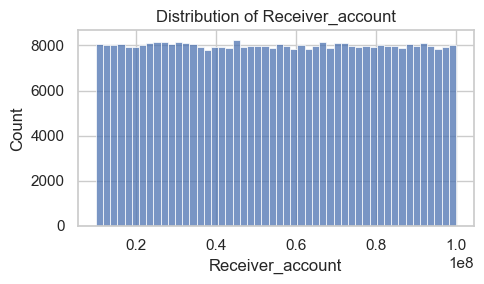

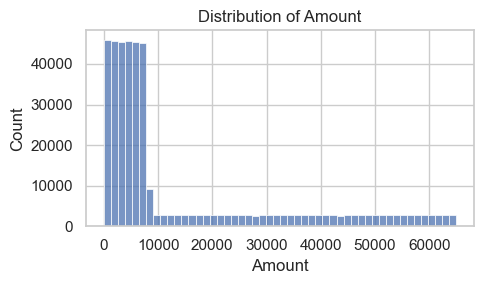

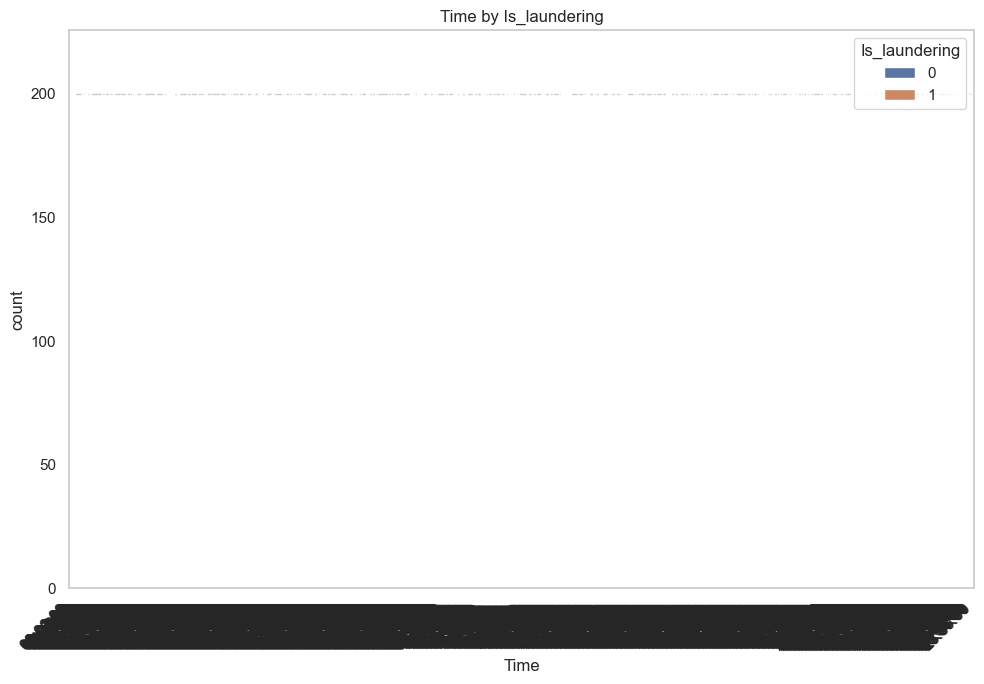

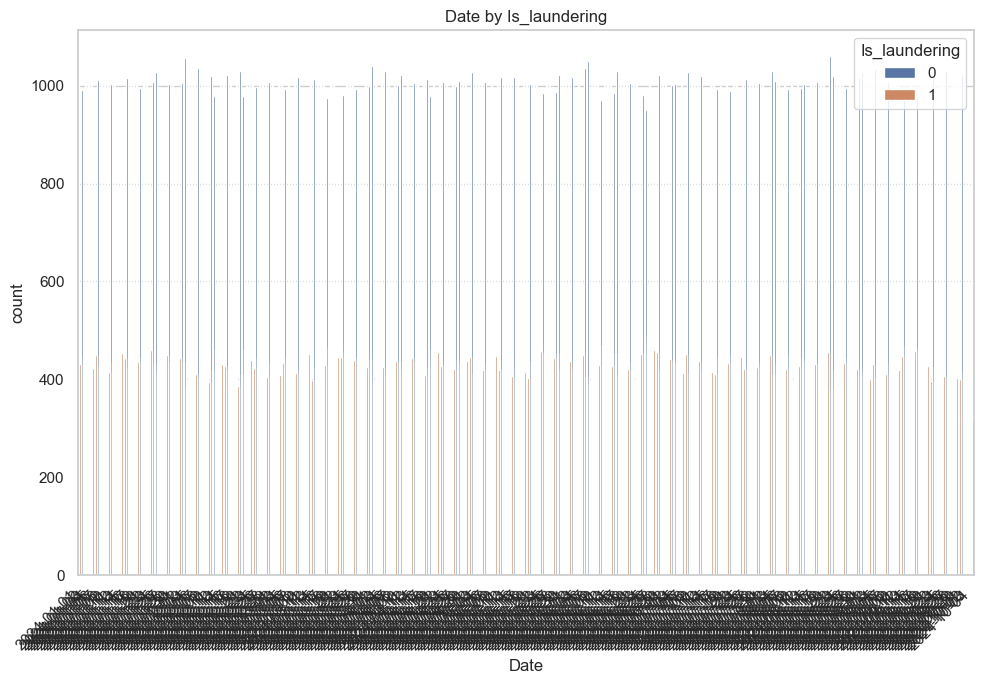

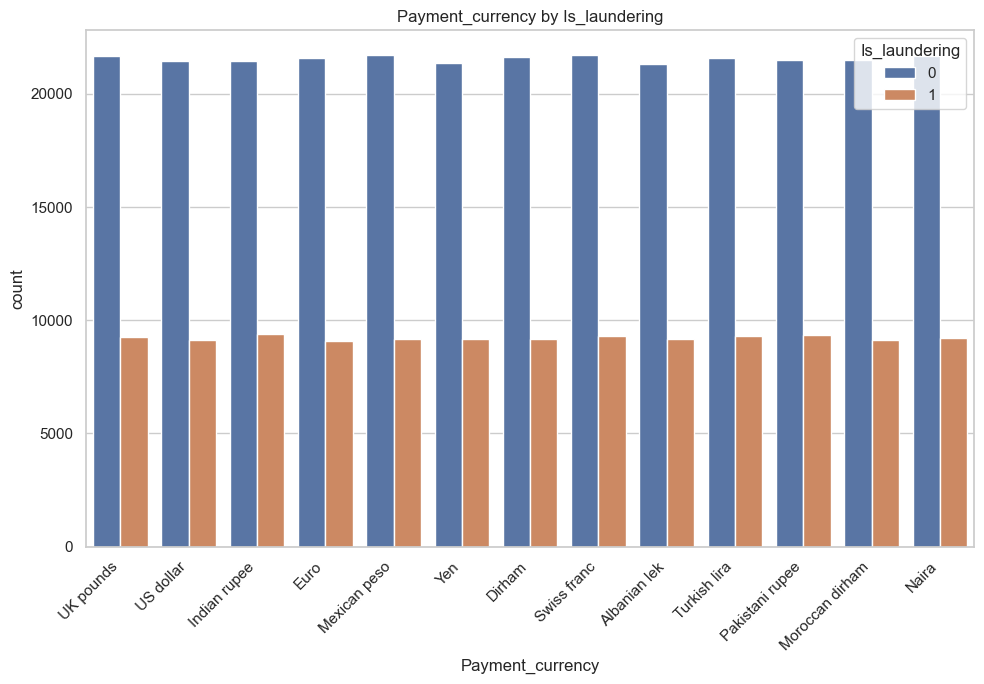

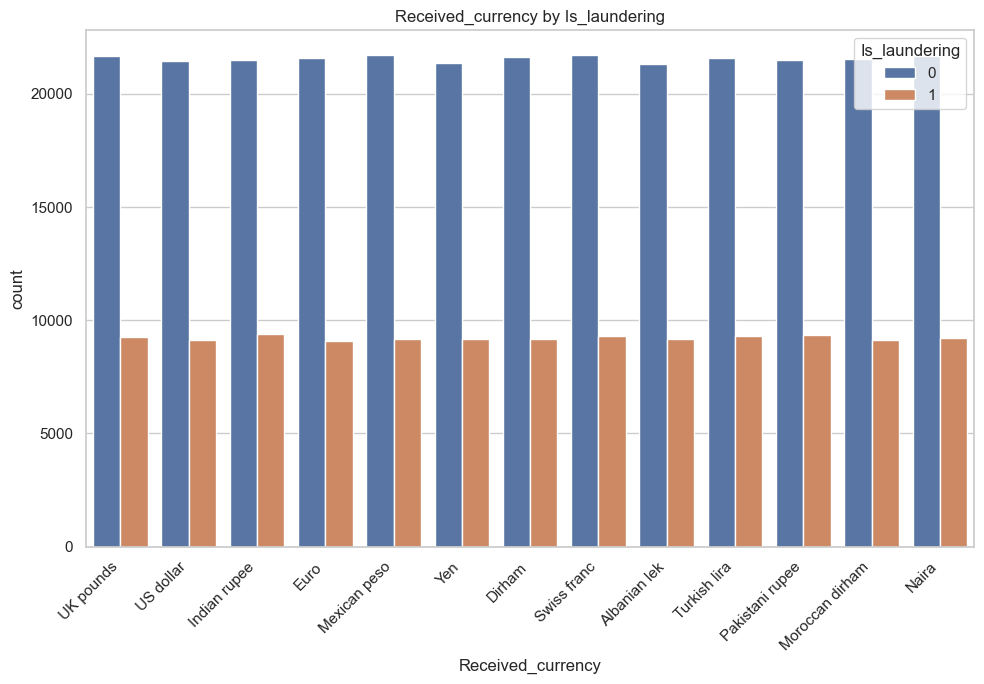

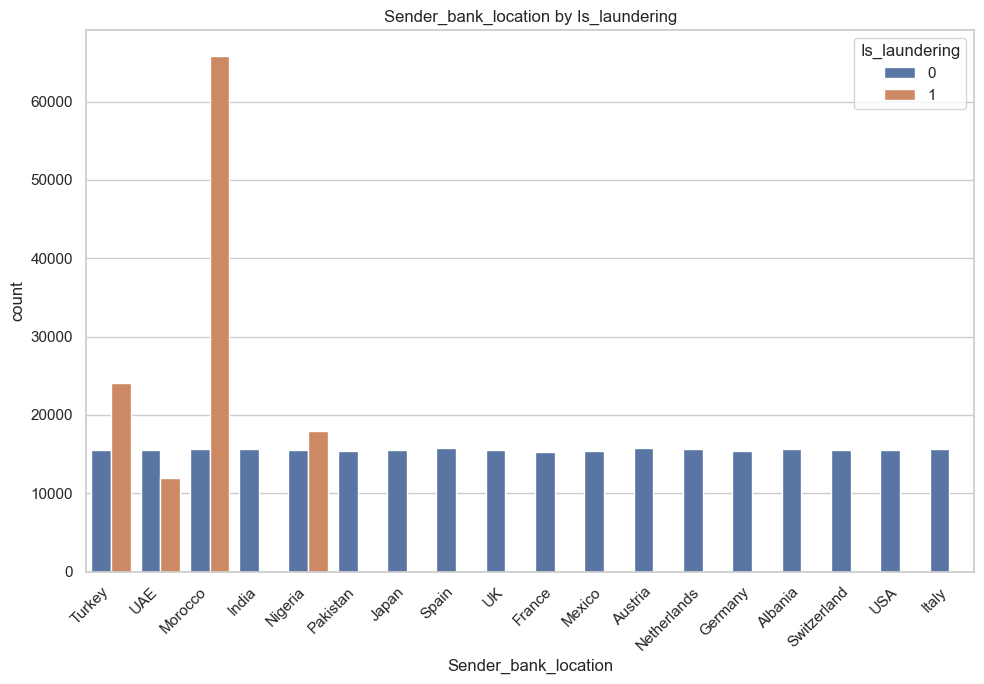

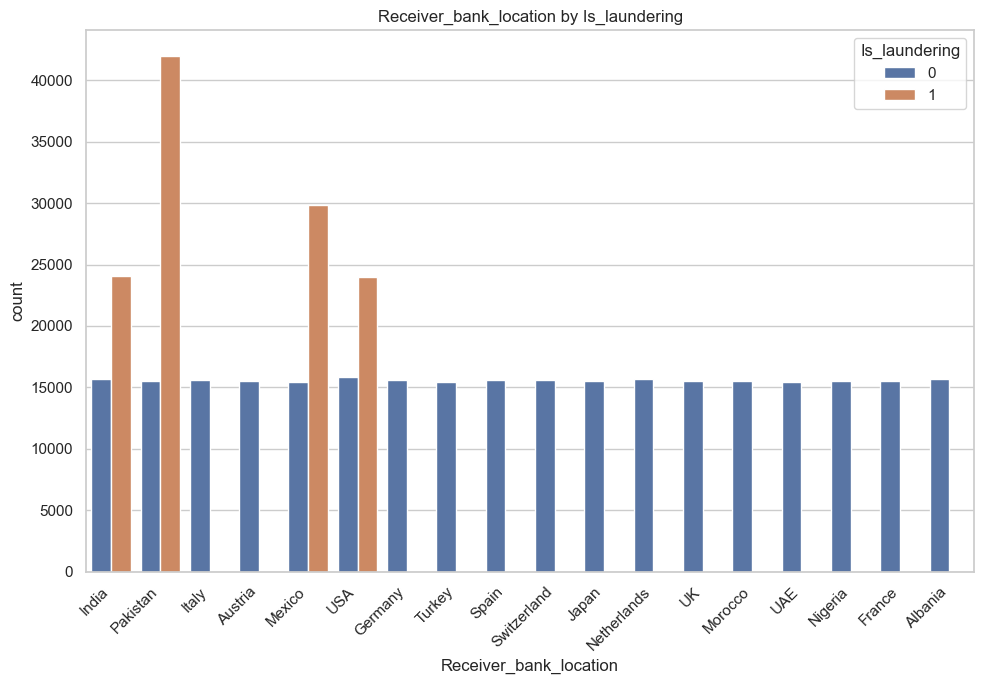

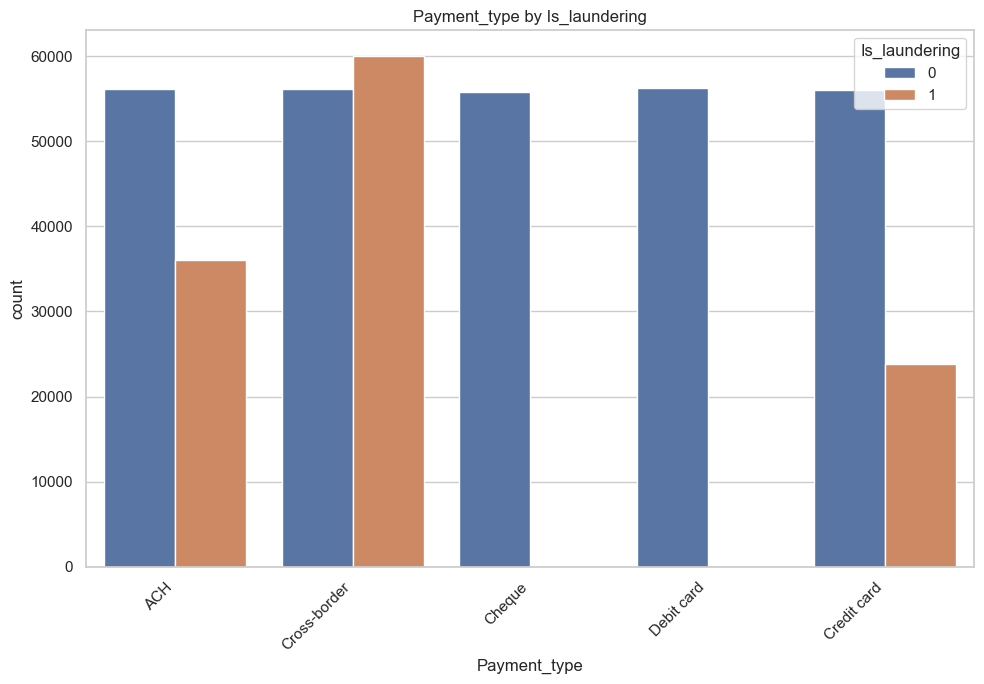

In [60]:
#numeric and categorical features
feature_df = df.drop(columns=[TARGET_COL]) if TARGET_COL in df.columns else df.copy()

numeric_features = feature_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = feature_df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

#histograms
for col in numeric_features[:3]:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], bins=50, kde=False)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

#bar charts
if TARGET_COL in df.columns and len(categorical_features) > 0:
    for col in categorical_features[:7]:
        plt.figure(figsize=(10,7))
        sns.countplot(data=df, x=col, hue=TARGET_COL)
        plt.title(f"{col} by {TARGET_COL}")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


## 3. Preprocessing
1. Separate features (X) and target (y).  
2. Ensure the target is numeric (0/1).  
3. Build a preprocessing pipeline:
   - Numeric features: impute missing values with the median, then scale.  
   - Categorical features: impute missing values with the most frequent value, then one-hot encode.  
4. Split data into training and test sets with a stratified split to preserve class balance.


In [61]:
# Separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].copy()

print("Original target dtype:", y.dtype)
print("Unique values in target:", y.unique())

# If target is non-numeric, convert to categorical
target_mapping = None
if not np.issubdtype(y.dtype, np.number):
    y_cat = y.astype("category")
    target_mapping = dict(enumerate(y_cat.cat.categories))
    y = y_cat.cat.codes
    print("\nTarget column converted to 0 and 1.")
    print(target_mapping)

#Binary classification check
n_classes = y.nunique()
print("\nUnique classes in target:", n_classes)
if n_classes != 2:
    print("Something other than 1 or 0 found in Is_laundering")

#numeric & categorical features based on X
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape, "Test shape:", X_test.shape)

Original target dtype: int64
Unique values in target: [1 0]

Unique classes in target: 2

Numeric features: ['Sender_account', 'Receiver_account', 'Amount']
Categorical features: ['Time', 'Date', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type']

Train shape: (320000, 10) Test shape: (80000, 10)


In [62]:
# Defined preprocessing for all data

numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),("cat", categorical_transformer, categorical_features)])
print("Preprocessing pipeline created.")

Preprocessing pipeline created.


## 4. Modeling: Logistic Regression and Random Forest
1. Logistic Regression – a linear, interpretable baseline model.  
2. Random Forest Classifier – a collection of decision trees that can capture nonlinear relationships.

In [63]:
# Logistic Regression pipeline
log_reg_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

# Random Forest pipeline
rf_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        n_jobs=-1,
        class_weight="balanced",
        random_state=42
    ))
])

In [64]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)

    mse = mean_squared_error(y_test, y_pred)
    sse = mse * len(y_test)

    print(f"{name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"MSE      : {mse:.6f}  (misclassification rate)")
    print(f"SSE      : {sse:.0f}  (# of misclassified samples)")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "mse": mse, "sse": sse,}

Logistic Regression
Accuracy : 0.9986
Precision: 0.9953
Recall   : 0.9999
MSE      : 0.001437  (misclassification rate)
SSE      : 115  (# of misclassified samples)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56030
           1       1.00      1.00      1.00     23970

    accuracy                           1.00     80000
   macro avg       1.00      1.00      1.00     80000
weighted avg       1.00      1.00      1.00     80000



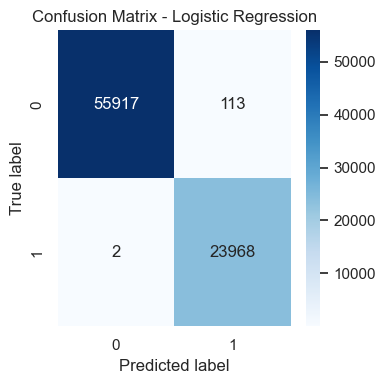

Random Forest
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
MSE      : 0.000000  (misclassification rate)
SSE      : 0  (# of misclassified samples)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56030
           1       1.00      1.00      1.00     23970

    accuracy                           1.00     80000
   macro avg       1.00      1.00      1.00     80000
weighted avg       1.00      1.00      1.00     80000



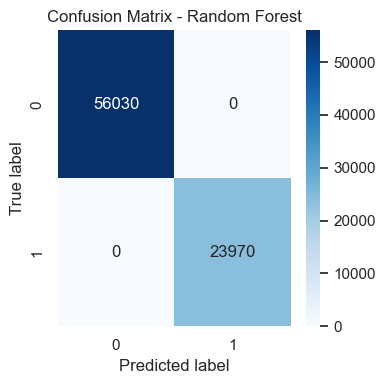


 Model comparison


,model,accuracy,precision,recall,mse,sse
0,Logistic Regression,0.998563,0.995308,0.999917,0.001437,115.0
1,Random Forest,1.000000,1.000000,1.000000,0.000000,0.0


In [65]:
results = []
results.append(evaluate_model("Logistic Regression", log_reg_clf, X_train, y_train, X_test, y_test))
results.append(evaluate_model("Random Forest", rf_clf, X_train, y_train, X_test, y_test))
results_df = pd.DataFrame(results)
print("\n Model comparison")
display(results_df)